In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.nn.utils.fusion import fuse_conv_bn_eval

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import numpy as np

from datetime import datetime
from time import time
import copy

In [2]:
from onnx2pytorch import ConvertModel

In [3]:
import json_to_pytorch

In [4]:
from pathlib import Path

def get_loaders(batch_size=64, num_workers=2, train_csv="../datasets/mnist_train.csv", test_csv="../datasets/mnist_test.csv"):
    def load_mnist_csv(csv_path):
        data = np.loadtxt(csv_path, delimiter=",", dtype=np.float64)
        labels = torch.from_numpy(data[:, 0].astype(np.int64))
        pixels = data[:, 1:] / 255.0

        images = np.reshape(pixels, (-1, 28, 28)) #, order="F")
        images = torch.from_numpy(images).unsqueeze(1)  # [N, 1, 28, 28]

        return torch.utils.data.TensorDataset(images, labels)

    train_ds = load_mnist_csv(train_csv)
    test_ds = load_mnist_csv(test_csv)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )
    return train_loader, test_loader

In [5]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

In [6]:
train_loader, test_loader = get_loaders(batch_size=128)

# Noise 2/255

## ReLU Model

In [ ]:
test_model = json_to_pytorch.json_to_pytorch("mnist/mnist_relu.json", double_precision=True)

In [ ]:
test_model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ChebyshevPoly()
  (3): Linear(in_features=256, out_features=256, bias=True)
  (4): ChebyshevPoly()
  (5): Linear(in_features=256, out_features=256, bias=True)
  (6): ChebyshevPoly()
  (7): Linear(in_features=256, out_features=256, bias=True)
  (8): ChebyshevPoly()
  (9): Linear(in_features=256, out_features=10, bias=True)
)

In [ ]:
# Import onnx model
onnx_model = onnx.load("../networks/mnist/mnist_256x4_1e4.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [ ]:
reference_loss,  reference_acc  = evaluate(reference_model, test_loader, criterion, "cpu")
print(f"Reference model - Loss: {reference_loss:.4f}, Accuracy: {reference_acc:.4f}")
test_loss,  test_acc  = evaluate(test_model, test_loader, criterion, "cpu")
print(f"Test model - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

Reference model - Loss: 0.0737, Accuracy: 0.9761
Test model - Loss: 0.0743, Accuracy: 0.9758
Test model - Loss: 0.0743, Accuracy: 0.9758


In [ ]:
import attack

In [ ]:
adv = attack.Adversary(attacks_iter=10, attack_restarts=10, attack_epsilon=2.0/255.0)

### Provable Bounds

In [ ]:
robust_eval_results = attack.robust_eval(reference_model, test_model, test_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [ ]:
robust_eval_results

{'normal_loss_ref': 0.0005759703949376859,
 'normal_loss_test': 0.0005807262401359267,
 'adv_loss_ref': 0.0005910655376369363,
 'adv_loss_test': 0.0005967006836881464,
 'normal_acc_ref': 0.9761,
 'normal_acc_test': 0.9758,
 'adv_acc_ref': 0.9748,
 'adv_acc_test': 0.9741,
 'normal_eq': 0.9987,
 'adv_eq': 0.9829,
 'total': 10000}

### Sampled Bounds

In [ ]:
test_model_sampled = json_to_pytorch.json_to_pytorch("mnist/mnist_relu_sampled.json", double_precision=True)

In [ ]:
test_loss,  test_acc  = evaluate(test_model_sampled, test_loader, criterion, "cpu")
print(f"Test model - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test model - Loss: 0.0740, Accuracy: 0.9757


In [ ]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, test_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
robust_eval_results_sampled

{'normal_loss_ref': 0.0005759703949376859,
 'normal_loss_test': 0.0005787829693147559,
 'adv_loss_ref': 0.0005901674725557729,
 'adv_loss_test': 0.0005934792002493749,
 'normal_acc_ref': 0.9761,
 'normal_acc_test': 0.9757,
 'adv_acc_ref': 0.9761,
 'adv_acc_test': 0.9738,
 'normal_eq': 0.9991,
 'adv_eq': 0.9833,
 'total': 10000}

## GeLU Model

In [ ]:
# Import onnx model
onnx_model = onnx.load("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [ ]:
test_model = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu.json", double_precision=True)

In [ ]:
reference_loss,  reference_acc  = evaluate(reference_model, test_loader, criterion, "cpu")
print(f"Reference model - Loss: {reference_loss:.4f}, Accuracy: {reference_acc:.4f}")
test_loss,  test_acc  = evaluate(test_model, test_loader, criterion, "cpu")
print(f"Test model - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

Reference model - Loss: 0.0777, Accuracy: 0.9780
Test model - Loss: 0.0777, Accuracy: 0.9780
Test model - Loss: 0.0777, Accuracy: 0.9780


In [ ]:
adv = attack.Adversary(attacks_iter=10, attack_restarts=10, attack_epsilon=2.0/255.0)

### Provable Bounds

In [ ]:
robust_eval_results = attack.robust_eval(reference_model, test_model, test_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [ ]:
robust_eval_results

{'normal_loss_ref': 0.0006066600541214301,
 'normal_loss_test': 0.0006066635485584552,
 'adv_loss_ref': 0.0006044182060657365,
 'adv_loss_test': 0.0006044240188252697,
 'normal_acc_ref': 0.978,
 'normal_acc_test': 0.978,
 'adv_acc_ref': 0.9762,
 'adv_acc_test': 0.9765,
 'normal_eq': 1.0,
 'adv_eq': 0.999,
 'total': 10000}

### Sampled Bounds

In [ ]:
test_model_sampled = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu_sampled.json", double_precision=True)

In [ ]:
test_loss,  test_acc  = evaluate(test_model_sampled, test_loader, criterion, "cpu")
print(f"Test model - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

Test model - Loss: 0.0777, Accuracy: 0.9780


In [ ]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, test_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [ ]:
robust_eval_results_sampled

{'normal_loss_ref': 0.0006066600541214301,
 'normal_loss_test': 0.0006066600827556387,
 'adv_loss_ref': 0.0006051833807386432,
 'adv_loss_test': 0.0006051834142612927,
 'normal_acc_ref': 0.978,
 'normal_acc_test': 0.978,
 'adv_acc_ref': 0.9756,
 'adv_acc_test': 0.9756,
 'normal_eq': 1.0,
 'adv_eq': 1.0,
 'total': 10000}

# Worst Case Noise

## GeLU

In [7]:
test_img = test_loader.dataset[0][0].unsqueeze(0)  # [1, 1, 28, 28]

In [8]:
# Import onnx model
onnx_model = onnx.load("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [9]:
test_model_sampled = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu_sampled.json", double_precision=True)

In [10]:
import attack

In [11]:
adv = attack.Adversary(attacks_iter=10, attack_restarts=10, attack_epsilon=0.9)

### Sampled Bounds

In [12]:
robust_eval_results_sampled = attack.robust_eval(reference_model, test_model_sampled, test_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [13]:
robust_eval_results_sampled

{'normal_loss_ref': 0.0006066600541214301,
 'normal_loss_test': 0.0006066600827556387,
 'adv_loss_ref': 0.07438238443048678,
 'adv_loss_test': nan,
 'normal_acc_ref': 0.978,
 'normal_acc_test': 0.978,
 'adv_acc_ref': 0.1352,
 'adv_acc_test': 0.0958,
 'normal_eq': 1.0,
 'adv_eq': 0.051,
 'total': 10000}

### Provable Bounds

In [14]:
test_model = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu.json", double_precision=True)

In [16]:
robust_eval_results = attack.robust_eval(reference_model, test_model, test_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [17]:
robust_eval_results

{'normal_loss_ref': 0.0006066600541214301,
 'normal_loss_test': 0.0006066635485584552,
 'adv_loss_ref': 0.0726111786346067,
 'adv_loss_test': 0.07261116619325059,
 'normal_acc_ref': 0.978,
 'normal_acc_test': 0.978,
 'adv_acc_ref': 0.1012,
 'adv_acc_test': 0.1012,
 'normal_eq': 1.0,
 'adv_eq': 0.997,
 'total': 10000}

# Other Experiments

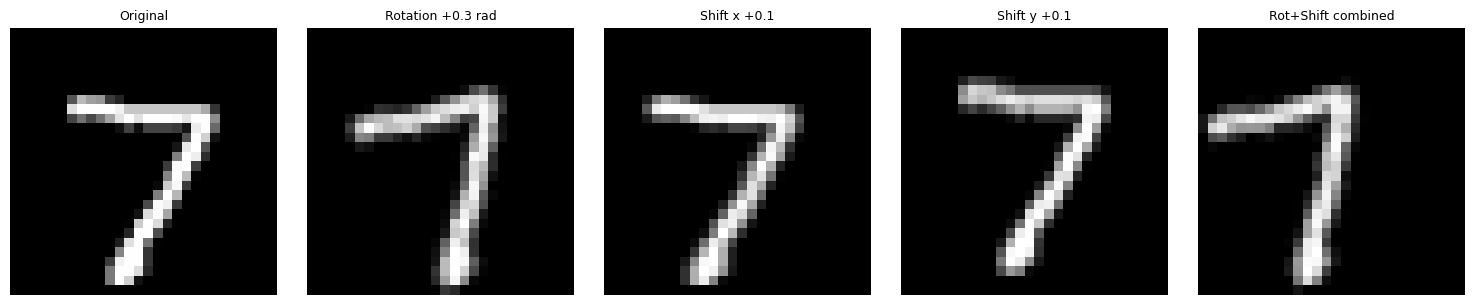

In [17]:
import importlib; importlib.reload(attack)
import matplotlib.pyplot as plt

# test_img should be a tensor of shape [1, C, H, W]
# Try a few specific (theta, tx, ty) combinations to inspect the transformation visually
params = [
    (0.0,  0.0,  0.0,  "Original"),
    (0.3,  0.0,  0.0,  "Rotation +0.3 rad"),
    (0.0,  0.1,  0.0,  "Shift x +0.1"),
    (0.0,  0.0,  0.1,  "Shift y +0.1"),
    (0.3,  0.25,  0.1,  "Rot+Shift combined"),
]

fig, axes = plt.subplots(1, len(params), figsize=(3 * len(params), 3))
affine_adv = attack.AffineAdversary()

for ax, (theta, tx, ty, title) in zip(axes, params):
    delta = torch.tensor([[theta, tx, ty]], dtype=test_img.dtype)
    perturbed = affine_adv.compute_perturbed_input(test_img.double(), delta)
    img_np = perturbed.squeeze().detach().numpy()
    ax.imshow(img_np, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
adv2 = attack.AffineAdversary(attacks_iter=10, attack_restarts=10, epsilon_rot=1.5, epsilon_tx=0.5, epsilon_ty=0.5)

In [26]:
attack.robust_eval(reference_model, test_model_sampled, small_loader, torch.nn.CrossEntropyLoss(), "cpu", adv2)

-------
0
Loss:  tensor(6.2449, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 0 - Number of same predictions: 100/100
1
Loss:  tensor(4.8509, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 1 - Number of same predictions: 100/100
2
Loss:  tensor(5.5816, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 2 - Number of same predictions: 100/100
3
Loss:  tensor(5.2424, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 3 - Number of same predictions: 100/100
4
Loss:  tensor(5.4225, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 4 - Number of same predictions: 100/100
5
Loss:  tensor(5.1998, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 5 - Number of same predictions: 100/100
6
Loss:  tensor(5.5855, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 6 - Number of same predictions: 100/100
7
Loss:  tensor(5.4083, dtype=torch.float64, grad_fn=<MeanBackward0>)
Attack iter 7 - Number of same predictions: 100/100
8
Loss:  tensor(

{'normal_loss_ref': 0.00019539015232545017,
 'normal_loss_test': 0.00019539020678028217,
 'adv_loss_ref': 0.0521844131246715,
 'adv_loss_test': 0.05218441508763957,
 'normal_acc_ref': 1.0,
 'normal_acc_test': 1.0,
 'adv_acc_ref': 0.14,
 'adv_acc_test': 0.14,
 'normal_eq': 1.0,
 'adv_eq': 1.0,
 'total': 100}

# GeLU Model

In [ ]:
# Import onnx model
onnx_model = onnx.load("../networks/mnist/mnist_gelu_256x4_1e4.onnx")
onnx.checker.check_model(onnx_model)
# convert it to pytorch
reference_model = ConvertModel(onnx_model).double()

In [ ]:
test_model = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu.json", double_precision=True)

In [ ]:
reference_loss,  reference_acc  = evaluate(reference_model, test_loader, criterion, "cpu")
print(f"Reference model - Loss: {reference_loss:.4f}, Accuracy: {reference_acc:.4f}")
test_loss,  test_acc  = evaluate(test_model, test_loader, criterion, "cpu")
print(f"Test model - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

Reference model - Loss: 0.0777, Accuracy: 0.9780
Test model - Loss: 0.0777, Accuracy: 0.9780


In [ ]:
adv = attack_internal.InternalAdversary(attacks_iter=100, attack_restarts=5, attack_epsilon=10.0/255.0)

In [ ]:
adv.reference_module_id = "Gemm_/fc1/Gemm_output_0"
adv.test_module_id = "3"

## Provable Bounds

In [ ]:
robust_eval_results = attack_internal.robust_eval(reference_model, test_model, small_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [ ]:
robust_eval_results

{'normal_loss_ref': 0.00019539015232545017,
 'normal_loss_test': 0.0001954611838232199,
 'adv_loss_ref': 0.0004052972267528136,
 'adv_loss_test': 0.0004053314322937676,
 'normal_acc_ref': 1.0,
 'normal_acc_test': 1.0,
 'adv_acc_ref': 0.99,
 'adv_acc_test': 0.99,
 'normal_eq': 1.0,
 'adv_eq': 1.0,
 'total': 100}

In [ ]:
test_model_sampled = json_to_pytorch.json_to_pytorch("mnist/mnist_gelu_sampled.json", double_precision=True)

In [ ]:
test_loss,  test_acc  = evaluate(test_model_sampled, test_loader, criterion, "cpu")
print(f"Test model - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

/home/samuel/Dokumente/Projects/NNV/FHE/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test model - Loss: 0.0777, Accuracy: 0.9780


In [ ]:
import attack_internal2

In [ ]:
#adv = attack_internal.InternalAdversary(attacks_iter=100, attack_restarts=5, attack_epsilon=10.0/255.0)
#adv.reference_module_id = "Gelu_/gelu0/Gelu_output_0"
#adv.test_module_id = "2"
#
#adv = attack.Adversary(attacks_iter=10, attack_restarts=10, attack_epsilon=20.0/255.0)
adv = attack_internal2.InternalAdversary(attacks_iter=10, attack_restarts=10, attack_epsilon=20.0/255.0)
adv.test_module_id = "6"

In [ ]:
# 10x50
robust_eval_results_sampled = attack_internal2.robust_eval(reference_model, test_model_sampled, small_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

------
Loss: -0.1356569789065526
Loss: -0.14273387241270843
Loss: -0.148587373219512
Loss: -0.153156728998287
Loss: -0.15634639527801864
Loss: -0.1574486090854139
Loss: -0.15818091501582515
Loss: -0.1586043292945462
Loss: -0.15876433449882105
Loss: -0.1587957694052356
------
Loss: -0.1356965228431724
Loss: -0.1427304429507671
Loss: -0.1485177551313356
Loss: -0.15305162845743528
Loss: -0.1562577713545485
Loss: -0.15738721279720871
Loss: -0.15814526584827218
Loss: -0.15859950480289012
Loss: -0.1587708465233072
Loss: -0.1588017782773027
------
Loss: -0.13586597974440154
Loss: -0.14285881490480906
Loss: -0.14867096582912234
Loss: -0.15317671321165385
Loss: -0.15636374236070996
Loss: -0.15748045967676455
Loss: -0.15820999374409975
Loss: -0.1586317449185785
Loss: -0.15878622444241533
Loss: -0.15881278453504336
------
Loss: -0.13570655585813685
Loss: -0.14269526157567908
Loss: -0.14851913235143555
Loss: -0.15308430516223648
Loss: -0.15629924077926488
Loss: -0.15741266907448906
Loss: -0.158140

In [ ]:
robust_eval_results_sampled

{'normal_loss_ref': 0.0005298254226161338,
 'normal_loss_test': 0.00019539020678028217,
 'adv_loss_ref': 0.0004984055807832097,
 'adv_loss_test': 0.00020192259678141085,
 'normal_acc_ref': 0.98,
 'normal_acc_test': 1.0,
 'adv_acc_ref': 0.97,
 'adv_acc_test': 1.0,
 'normal_eq': 0.98,
 'adv_eq': 0.97,
 'total': 100}

In [ ]:
# 2x250
robust_eval_results_sampled = attack_internal.robust_eval(reference_model, test_model_sampled, small_loader, torch.nn.CrossEntropyLoss(), "cpu", adv)

In [ ]:
robust_eval_results_sampled

{'normal_loss_ref': 0.00019539015232545017,
 'normal_loss_test': 0.00019539020678028217,
 'adv_loss_ref': 0.00040433275937243156,
 'adv_loss_test': 0.00040433274665348907,
 'normal_acc_ref': 1.0,
 'normal_acc_test': 1.0,
 'adv_acc_ref': 0.99,
 'adv_acc_test': 0.99,
 'normal_eq': 1.0,
 'adv_eq': 1.0,
 'total': 100}

In [ ]:
robust_eval_results_sampled

{'normal_loss_ref': 0.00019539015232545017,
 'normal_loss_test': 0.00019539020678028217,
 'adv_loss_ref': 0.06341425002173684,
 'adv_loss_test': nan,
 'normal_acc_ref': 1.0,
 'normal_acc_test': 1.0,
 'adv_acc_ref': 0.32,
 'adv_acc_test': 0.08,
 'normal_eq': 1.0,
 'adv_eq': 0.0,
 'total': 100}